In [1]:
# generate some linear looking data to test the normal equation
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

In [2]:
# Take a look at the data 
print(f"X data generated: {X[:5]} \n")
print(f"Y data generated: {y[:5]}")

X data generated: [[0.78279466]
 [1.76814469]
 [1.22772658]
 [1.69631962]
 [1.49806276]] 

Y data generated: [[5.1935597 ]
 [7.93919501]
 [9.10624406]
 [8.67280594]
 [8.08461207]]


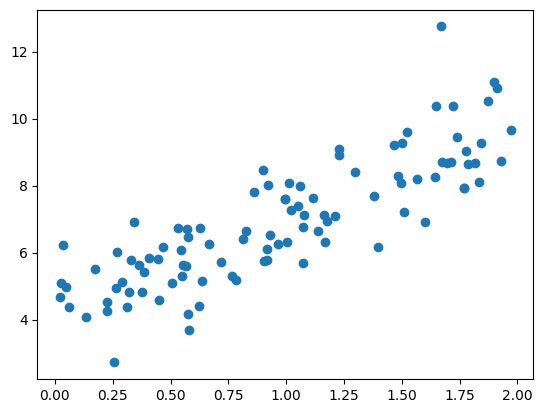

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
# calculate the hypothesis parameter 
X_b = np.c_[np.ones((100,1)),X] # add x0 =1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

[[4.22434006]
 [2.78381507]]


The actual parameters are 4 and 3, we got 4.22 and 2.87 due to the Gaussian noises we added

In [5]:
# make predictions using theta 
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]# add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
print(y_predict)

[[4.22434006]
 [9.79197019]]


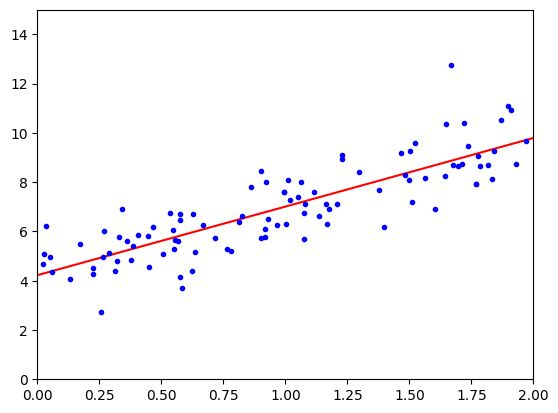

In [6]:
# plot the model's predictions
plt.plot(X_new, y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [7]:
# perform linear regression 
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_)
print(lin_reg.coef_)
print(lin_reg.predict(X_new))



[4.22434006]
[[2.78381507]]
[[4.22434006]
 [9.79197019]]


In [8]:
# use the least squares function instead
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.22434006],
       [2.78381507]])

In [9]:
np.linalg.pinv(X_b).dot(y)

array([[4.22434006],
       [2.78381507]])

In [10]:
# implement batch gradient descent
eta = 0.1 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2,1) # random initialisation

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

print(theta)

[[4.22434006]
 [2.78381507]]


In [12]:
# implementing stochastic gradient descent 
n_epochs = 50
t0, t1 = 5,50 # learning schedule hyperparameters 

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2,1) # random initialisation

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi =X_b[random_index: random_index+1]
    yi =y[random_index: random_index+1]
    gradients = 2*xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch*m + i)
    theta = theta - eta * gradients

print(theta)

[[4.24491431]
 [2.80974325]]


To ensure the parameters are getting pulled towards the global optimum, we can shuffle the instances during training

In [13]:
# perform linear regression using SGD with sklearn
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X,y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.18995053]), array([2.79063366]))

Polynomial Regression 
Using a linear model to fit nonlinear data

In [14]:
# generate nonlinear data 
m = 100
X = 6 * np.random.rand(m, 1) -3 # add noise
y = 0.5 * X**2 + X +2 + np.random.randn(m,1) # quadratic eqn and added noise


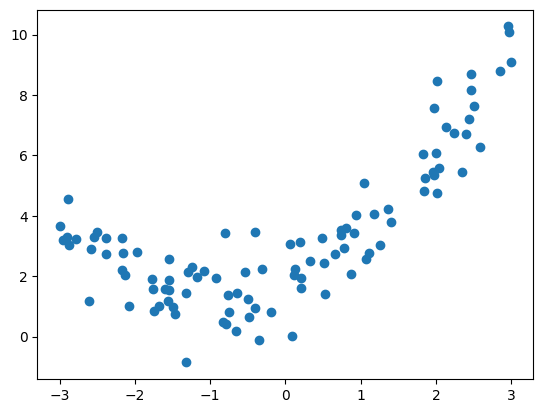

In [15]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [16]:
# use sklearn's polynomial class to transform the training data
# adding the square of each feature in the training set as new features
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0], X_poly[0])

[1.25041788] [1.25041788 1.56354487]


In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[1.81722027] [[0.98906305 0.54062023]]


In [27]:
X_plot = np.linspace(-3,3,100).reshape(100,1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)

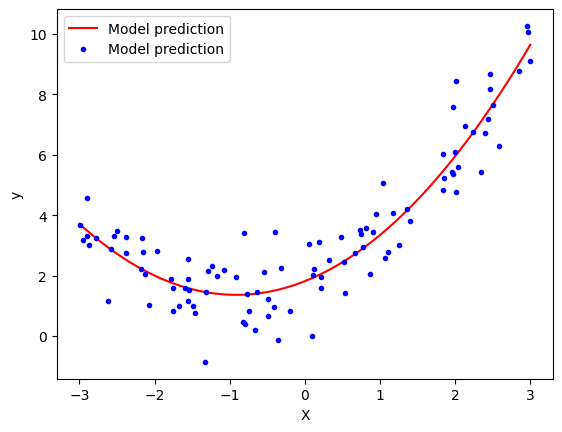

In [ ]:
# plot the model's predictions
plt.plot(X_plot,y_plot, "r-", label="Model prediction")
plt.plot(X,y,"b.", label="Model prediction")
plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()